In [1]:
# Vaihe 4: Mallien koulutus
# Alustus: importit + datan lataus

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lataa Vaiheen 3 lopullinen välitallennus
setups_with_features = pd.read_parquet(
    '../data/processed/setups_with_features.parquet'
)

print(f"Rivejä: {len(setups_with_features):,}")
print(f"Sarakkeita: {len(setups_with_features.columns)}")
print(f"Sarakkeet: {list(setups_with_features.columns)}")

Rivejä: 8,281
Sarakkeita: 34
Sarakkeet: ['setup_id', 'symbol', 'date', 'direction', 'setup_index_in_day', 'box_high', 'box_low', 'box_mid', 'entry_time', 'entry_price', 'stop_loss', 'take_profit', 'risk_reward_ratio', 'outcome_time', 'outcome', 'label', 'date_only', 'entry_outside_box', 'entry_position_in_box', 'hour_sin', 'hour_cos', 'prev_day_range_pct', 'box_size_vs_atr14d', 'ema50_4h', 'ema200_4h', 'trend_4h', 'trend_aligned', 'volume_vs_ma20_15m', 'rsi_1h', 'atr_15m_vs_atr_daily', 'atr_1h_pct', 'reversal_candle_time', 'reversal_candle_size_pct', 'minutes_in_opposite_half']


In [2]:
# Mallinnukseen vain labeled-setupit (expired-setupit pois)
df_ml = setups_with_features[setups_with_features['label'].notna()].copy()
df_ml['label'] = df_ml['label'].astype(int)

print(f"Labeled setupit: {len(df_ml):,}")
print(f"Voitto-%: {df_ml['label'].mean() * 100:.2f}%")
print(f"\nJako symboleittain:")
print(df_ml['symbol'].value_counts())
print(f"\nJako suunnittain:")
print(df_ml['direction'].value_counts())

Labeled setupit: 6,641
Voitto-%: 7.06%

Jako symboleittain:
symbol
SOLUSDT    3457
ETHUSDT    3184
Name: count, dtype: int64

Jako suunnittain:
direction
short    3345
long     3296
Name: count, dtype: int64


In [3]:
# Lisätään apusarake kuukausi-ryhmittelyä varten
df_ml['entry_month'] = df_ml['entry_time'].dt.to_period('M')

# Setupien lukumäärä kuukausittain
monthly_counts = df_ml.groupby('entry_month').size()

# Voitto-% kuukausittain (kontekstia varten)
monthly_winrate = df_ml.groupby('entry_month')['label'].mean() * 100

# Yhdistetään
monthly_summary = pd.DataFrame({
    'n_setups': monthly_counts,
    'win_pct': monthly_winrate.round(2)
})

print(monthly_summary.to_string())

             n_setups  win_pct
entry_month                   
2024-01           206     7.77
2024-02           222     8.56
2024-03           244     6.15
2024-04           229     6.11
2024-05           251     8.76
2024-06           214     7.48
2024-07           243     6.58
2024-08           239     3.35
2024-09           211     8.06
2024-10           239     6.28
2024-11           235     7.66
2024-12           260     8.08
2025-01           234     6.41
2025-02           248     6.85
2025-03           248     6.85
2025-04           219     8.22
2025-05           218    10.55
2025-06           215     6.05
2025-07           254     4.72
2025-08           256     4.69
2025-09           207    10.63
2025-10           251     7.57
2025-11           240     9.58
2025-12           217    11.98
2026-01           244     3.69
2026-02           266     3.38
2026-03           267     3.00
2026-04           215     8.84
2026-05            49    20.41


/var/folders/tl/3hfx77_15bb4qncz0wss0j180000gp/T/ipykernel_1762/1145879517.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ml['entry_month'] = df_ml['entry_time'].dt.to_period('M')


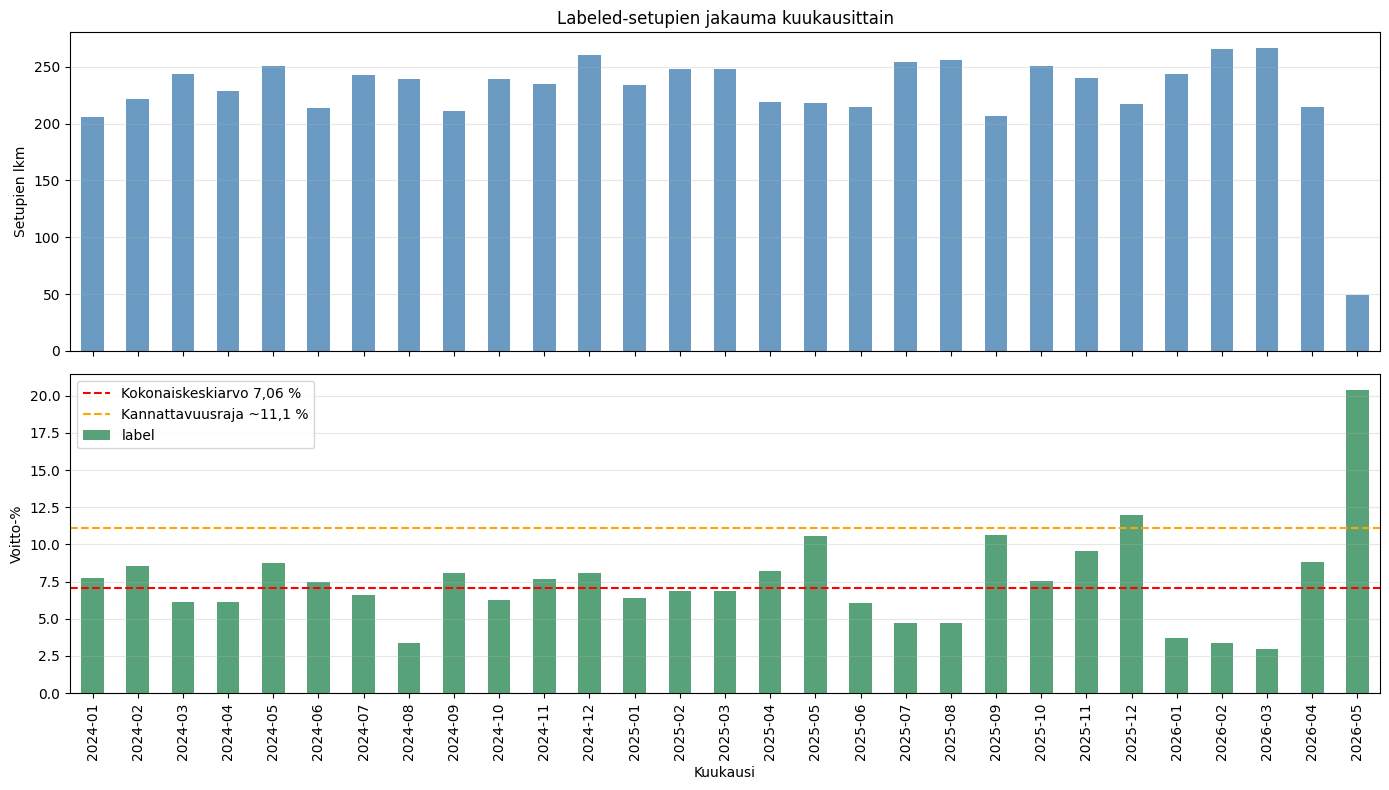

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Yläpaneeli: setupien lukumäärä per kuukausi
monthly_counts.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_ylabel('Setupien lkm')
ax1.set_title('Labeled-setupien jakauma kuukausittain')
ax1.grid(axis='y', alpha=0.3)

# Alapaneeli: voitto-% per kuukausi
monthly_winrate.plot(kind='bar', ax=ax2, color='seagreen', alpha=0.8)
ax2.axhline(y=7.06, color='red', linestyle='--', label='Kokonaiskeskiarvo 7,06 %')
ax2.axhline(y=11.1, color='orange', linestyle='--', label='Kannattavuusraja ~11,1 %')
ax2.set_ylabel('Voitto-%')
ax2.set_xlabel('Kuukausi')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
SPLIT_DATE = pd.Timestamp('2025-10-01', tz='UTC')

train_mask = df_ml['entry_time'] < SPLIT_DATE
test_mask = df_ml['entry_time'] >= SPLIT_DATE

print(f"Train:  n = {train_mask.sum():,}, voitto-% = {df_ml.loc[train_mask, 'label'].mean()*100:.2f}%")
print(f"Test:   n = {test_mask.sum():,}, voitto-% = {df_ml.loc[test_mask, 'label'].mean()*100:.2f}%")
print(f"Suhde:  train {train_mask.sum() / len(df_ml)*100:.1f}% / test {test_mask.sum() / len(df_ml)*100:.1f}%")
print(f"\nTrain symboleittain:")
print(df_ml.loc[train_mask, 'symbol'].value_counts())
print(f"\nTest symboleittain:")
print(df_ml.loc[test_mask, 'symbol'].value_counts())
print(f"\nTrain suunnittain:")
print(df_ml.loc[train_mask, 'direction'].value_counts())
print(f"\nTest suunnittain:")
print(df_ml.loc[test_mask, 'direction'].value_counts())

Train:  n = 4,892, voitto-% = 7.07%
Test:   n = 1,749, voitto-% = 7.03%
Suhde:  train 73.7% / test 26.3%

Train symboleittain:
symbol
SOLUSDT    2565
ETHUSDT    2327
Name: count, dtype: int64

Test symboleittain:
symbol
SOLUSDT    892
ETHUSDT    857
Name: count, dtype: int64

Train suunnittain:
direction
short    2580
long     2312
Name: count, dtype: int64

Test suunnittain:
direction
long     984
short    765
Name: count, dtype: int64


In [6]:
# EV-funktio: laskee odotusarvon setup-joukolle
# Käyttää oletusta että jokaisessa setupissa riskataan yksi yksikkö (1R)
# - Voitto: +R/R-suhde (esim. 7.8R long-mediaanille)
# - Tappio: -1R
# Lisäksi otetaan huomioon kustannukset (spread + fee)

def calculate_ev(df, cost_per_trade=0.0015):
    """
    Laskee odotusarvon R-yksiköissä (1 R = riskattu määrä per setup).
    
    Parametrit:
    - df: DataFrame jossa pitää olla 'label' (0/1) ja 'risk_reward_ratio' sarakkeet
    - cost_per_trade: spread + fee yhteensä per kauppa, prosenttina hintaliikkeestä
                      0.0015 = 0,15 % (Binance taker fee 0,1 % + tyypillinen spread 0,05 %)
                      
    Palauttaa dict:n jossa: n, win_pct, avg_win_R, ev_per_trade_R, total_R
    """
    if len(df) == 0:
        return {'n': 0, 'win_pct': 0, 'avg_win_R': 0, 'ev_per_trade_R': 0, 'total_R': 0}
    
    n = len(df)
    win_pct = df['label'].mean()
    
    # Voittojen R/R-suhde keskimäärin (vain voitoista)
    winning_rr = df.loc[df['label'] == 1, 'risk_reward_ratio']
    avg_win_R = winning_rr.mean() if len(winning_rr) > 0 else 0
    
    # EV per kauppa = P(voitto) * R/R - P(tappio) * 1 - kustannus
    # Kustannus arvioidaan karkeasti: ~2x cost_per_trade (entry + exit), jaettuna
    # tyypillisellä boxin keskiliikkeellä (jos liike on 2 %, kustannus 0,3 % = 0,15 R)
    # Yksinkertaistettuna: vähennetään kiinteä kustannus per kauppa R-yksiköissä
    cost_R = cost_per_trade * 2 / 0.02  # Karkea arvio: ~0,15 R per kauppa
    
    ev_per_trade_R = win_pct * avg_win_R - (1 - win_pct) * 1.0 - cost_R
    total_R = ev_per_trade_R * n
    
    return {
        'n': n,
        'win_pct': win_pct * 100,
        'avg_win_R': avg_win_R,
        'ev_per_trade_R': ev_per_trade_R,
        'total_R': total_R
    }


# Sanity-tarkistus koko treenidatalle
ev_train_all = calculate_ev(df_ml.loc[train_mask])
print("Koko treenidata, ei filtteröintiä:")
for k, v in ev_train_all.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Koko treenidata, ei filtteröintiä:
  n: 4892
  win_pct: 7.073
  avg_win_R: 5.679
  ev_per_trade_R: -0.678
  total_R: -3314.729


In [7]:
# Baseline 1a: "Älä ota mitään setupia" (täydellinen pidättäytyminen)
# EV per kauppa = 0 (ei kauppoja), total_R = 0
print("BASELINE 1a: Älä ota mitään")
print(f"  EV per kauppa: 0.000 R")
print(f"  Total R: 0.000")
print(f"  n: 0\n")

# Baseline 1b: "Ota kaikki" (= koko treenidata)
ev_b1b_train = calculate_ev(df_ml.loc[train_mask])
ev_b1b_test = calculate_ev(df_ml.loc[test_mask])

print("BASELINE 1b: Ota kaikki")
print(f"  TRAIN: n={ev_b1b_train['n']:,}, win%={ev_b1b_train['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b1b_train['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b1b_train['total_R']:+.1f} R")
print(f"  TEST:  n={ev_b1b_test['n']:,}, win%={ev_b1b_test['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b1b_test['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b1b_test['total_R']:+.1f} R")

BASELINE 1a: Älä ota mitään
  EV per kauppa: 0.000 R
  Total R: 0.000
  n: 0

BASELINE 1b: Ota kaikki
  TRAIN: n=4,892, win%=7.07%, EV/kauppa=-0.678 R, total=-3314.7 R
  TEST:  n=1,749, win%=7.03%, EV/kauppa=-0.660 R, total=-1153.5 R


In [8]:
# Baseline 2: Vain ensimmäinen setup per päivä
b2_train_mask = train_mask & (df_ml['setup_index_in_day'] == 1)
b2_test_mask = test_mask & (df_ml['setup_index_in_day'] == 1)

ev_b2_train = calculate_ev(df_ml.loc[b2_train_mask])
ev_b2_test = calculate_ev(df_ml.loc[b2_test_mask])

print("BASELINE 2: Vain ensimmäinen setup per päivä")
print(f"  TRAIN: n={ev_b2_train['n']:,}, win%={ev_b2_train['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b2_train['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b2_train['total_R']:+.1f} R")
print(f"  TEST:  n={ev_b2_test['n']:,}, win%={ev_b2_test['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b2_test['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b2_test['total_R']:+.1f} R")

BASELINE 2: Vain ensimmäinen setup per päivä
  TRAIN: n=1,199, win%=11.34%, EV/kauppa=-0.431 R, total=-516.2 R
  TEST:  n=411, win%=9.98%, EV/kauppa=-0.557 R, total=-228.9 R


In [9]:
# Baseline 3: Yhdistetty sääntöfiltteri (Vaiheen 3 löytöjen pohjalta)

# Lasketaan kynnysarvot VAIN treenidatasta (ei look-ahead-vuotoa)
train_df = df_ml.loc[train_mask]
box_atr_median = train_df['box_size_vs_atr14d'].median()
atr_1h_median = train_df['atr_1h_pct'].median()

print(f"Treenidatan mediaanit:")
print(f"  box_size_vs_atr14d: {box_atr_median:.3f}")
print(f"  atr_1h_pct: {atr_1h_median:.5f}")

# Sääntöfunktio joka soveltuu mihin tahansa DataFrame-osajoukkoon
def baseline3_filter(df, box_thr, atr_thr):
    """Palauttaa boolean-maskin niistä setupeista jotka läpäisevät yhdistetyn filtterin."""
    base_rules = (
        (df['minutes_in_opposite_half'] < 175) &
        (df['box_size_vs_atr14d'] < box_thr) &
        (df['atr_1h_pct'] < atr_thr)
    )
    # Direction-spesifi RSI-ehto
    long_ok = (df['direction'] == 'long') & (df['rsi_1h'] > 44)
    short_ok = (df['direction'] == 'short') & (df['rsi_1h'] < 56)
    direction_rule = long_ok | short_ok
    
    return base_rules & direction_rule

# Sovelletaan treeniin ja testiin
b3_train = df_ml.loc[train_mask][baseline3_filter(df_ml.loc[train_mask], box_atr_median, atr_1h_median)]
b3_test = df_ml.loc[test_mask][baseline3_filter(df_ml.loc[test_mask], box_atr_median, atr_1h_median)]

ev_b3_train = calculate_ev(b3_train)
ev_b3_test = calculate_ev(b3_test)

print(f"\nBASELINE 3: Yhdistetty sääntöfiltteri")
print(f"  TRAIN: n={ev_b3_train['n']:,} ({ev_b3_train['n']/train_mask.sum()*100:.1f}% setupeista), "
      f"win%={ev_b3_train['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b3_train['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b3_train['total_R']:+.1f} R")
print(f"  TEST:  n={ev_b3_test['n']:,} ({ev_b3_test['n']/test_mask.sum()*100:.1f}% setupeista), "
      f"win%={ev_b3_test['win_pct']:.2f}%, "
      f"EV/kauppa={ev_b3_test['ev_per_trade_R']:+.3f} R, "
      f"total={ev_b3_test['total_R']:+.1f} R")

Treenidatan mediaanit:
  box_size_vs_atr14d: 0.864
  atr_1h_pct: 0.01072

BASELINE 3: Yhdistetty sääntöfiltteri
  TRAIN: n=282 (5.8% setupeista), win%=24.47%, EV/kauppa=+0.117 R, total=+32.9 R
  TEST:  n=129 (7.4% setupeista), win%=17.05%, EV/kauppa=-0.330 R, total=-42.6 R


In [10]:
# Yhteenvetotaulukko kaikista baselineista
baseline_summary = pd.DataFrame([
    {'baseline': '1a: Älä ota mitään', 'set': 'train', 'n': 0, 'win_pct': 0, 'ev_per_trade_R': 0, 'total_R': 0},
    {'baseline': '1a: Älä ota mitään', 'set': 'test',  'n': 0, 'win_pct': 0, 'ev_per_trade_R': 0, 'total_R': 0},
    {'baseline': '1b: Ota kaikki', 'set': 'train', **{k: ev_b1b_train[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '1b: Ota kaikki', 'set': 'test',  **{k: ev_b1b_test[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '2: Ensimmäinen/päivä', 'set': 'train', **{k: ev_b2_train[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '2: Ensimmäinen/päivä', 'set': 'test',  **{k: ev_b2_test[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '3: Yhdistetty filtteri', 'set': 'train', **{k: ev_b3_train[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
    {'baseline': '3: Yhdistetty filtteri', 'set': 'test',  **{k: ev_b3_test[k] for k in ['n','win_pct','ev_per_trade_R','total_R']}},
])

print(baseline_summary.to_string(index=False))

              baseline   set    n   win_pct  ev_per_trade_R      total_R
    1a: Älä ota mitään train    0  0.000000        0.000000     0.000000
    1a: Älä ota mitään  test    0  0.000000        0.000000     0.000000
        1b: Ota kaikki train 4892  7.072772       -0.677582 -3314.728895
        1b: Ota kaikki  test 1749  7.032590       -0.659522 -1153.503919
  2: Ensimmäinen/päivä train 1199 11.342786       -0.430524  -516.198685
  2: Ensimmäinen/päivä  test  411  9.975669       -0.557039  -228.942846
3: Yhdistetty filtteri train  282 24.468085        0.116721    32.915211
3: Yhdistetty filtteri  test  129 17.054264       -0.330257   -42.603116


In [ ]:
# Tallennetaan baseline-tulokset
import os
os.makedirs('../models', exist_ok=True)
baseline_summary.to_parquet('../models/baseline_results.parquet')
print("Tallennettu: ../models/baseline_results.parquet")
print(f"\nLopulliset baseline-tulokset:")
print(baseline_summary.to_string(index=False))